# Delta Hedging and Adversarial Stock-Path Simulation

An end-to-end quantitative-finance research notebook for analysing discrete-time hedging of European options.

**Stack:** Python · NumPy · Pandas · SciPy · PyTorch · Monte Carlo simulation · Black–Scholes

## Overview

The notebook implements and compares classical and learned hedging approaches across simulated and stress-tested market paths:

| Module | Description |
|--------|-------------|
| **Black–Scholes Engine** | Pricing, Greeks (Δ, Γ, ν, Θ), Newton-Raphson IV solver |
| **3 Path Generators** | GBM, Merton Jump-Diffusion + Stochastic Vol, PyTorch Adversarial |
| **Hedging Engine** | Discrete-time delta hedge with 50–252 rebalancing intervals & transaction costs |
| **Neural-Network Hedger** | 2-layer LSTM (PyTorch) trained with CVaR loss |
| **Monte Carlo Analysis** | 10,000+ simulations, P&L distributions, VaR, CVaR, downside risk |

---
## Section 1 — Configuration, Imports & Data Loading

We begin by importing all necessary libraries and defining the simulation parameters. The configuration is calibrated to **NIFTY-50** market parameters, with optional auto-calibration from real CSV data if available.

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.dpi": 150,
})

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Imports loaded successfully")
print(f"   PyTorch version: {torch.__version__}")
print(f"   NumPy version:   {np.__version__}")

Imports loaded successfully
   PyTorch version: 2.11.0+cpu
   NumPy version:   2.1.3


### 1.1 — Simulation Parameters

All parameters are collected in a single configuration dictionary for easy modification. Key choices:
- **S₀ = 23,000** — typical NIFTY-50 level
- **K = S₀** — At-The-Money (ATM) option for maximum gamma exposure
- **T = 30/365** — 30-day European call option
- **σ = 18%** — annualised volatility (NIFTY historical range: 12–25%)
- **10,000 paths × 252 time-steps** — sufficient for stable Monte Carlo estimates

In [ ]:
CONFIG = {
    "S0"        : 23_000.0,      # initial spot / futures price
    "K"         : 23_000.0,      # strike (ATM)
    "T"         : 30 / 365,      # time to expiry  (≈30 calendar days)
    "r"         : 0.065,         # risk-free rate   (Indian 1-month T-bill)
    "sigma"     : 0.18,          # annualised vol   (NIFTY historical ~15-20%)
    "option_type": "call",       # European call
    # Monte Carlo
    "num_paths" : 10_000,
    "num_steps" : 252,           # time-steps per path (≥ max rebalance freq)
    # Hedging engine
    "rebalance_steps_list": [50, 84, 100, 150, 200, 252],
    "tc_prop"   : 0.001,         # proportional transaction cost  (10 bps)
    "tc_fixed"  : 0.50,          # fixed cost per rebalance (₹)
    # Neural-network hedger
    "lstm_hidden": 32,
    "lstm_layers": 2,
    "nn_epochs"  : 50,
    "nn_batch"   : 256,
    "nn_lr"      : 1e-3,
    "cvar_alpha" : 0.05,
    # Adversarial generator
    "adv_epochs" : 200,
    "adv_lr"     : 0.01,
    "adv_paths"  : 500,
}

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Configuration loaded")
for k, v in CONFIG.items():
    print(f"   {k:25s} = {v}")

Configuration loaded
   S0                        = 23000.0
   K                         = 23000.0
   T                         = 0.0821917808219178
   r                         = 0.065
   sigma                     = 0.18
   option_type               = call
   num_paths                 = 10000
   num_steps                 = 252
   rebalance_steps_list      = [50, 84, 100, 150, 200, 252]
   tc_prop                   = 0.001
   tc_fixed                  = 0.5
   lstm_hidden               = 32
   lstm_layers               = 2
   nn_epochs                 = 50
   nn_batch                  = 256
   nn_lr                     = 0.001
   cvar_alpha                = 0.05
   adv_epochs                = 200
   adv_lr                    = 0.01
   adv_paths                 = 500


### 1.2 — Real Data Loading & Calibration (Optional)

If NIFTY option CSV files are present in the working directory, we load them and **auto-calibrate** S₀ and σ from the futures time series. This grounds the simulation in real market data.

In [ ]:
DATA_DIR = "."

def load_real_data():
    """Load NIFTY option CSV files if present; return merged DataFrame."""
    csvs = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".csv")])
    if not csvs:
        print("[INFO] No CSV files found — using purely synthetic data.")
        return None
    frames = []
    for c in csvs:
        df = pd.read_csv(os.path.join(DATA_DIR, c))
        frames.append(df)
    merged = pd.concat(frames, ignore_index=True)
    print(f"[DATA] Loaded {len(merged):,} rows from {len(csvs)} CSV file(s): {csvs}")
    return merged

def extract_market_params(df):
    """
    Extract calibration parameters from real NIFTY data:
      • S0 from latest futures price
      • sigma from intraday returns of the futures
      • K is set = S0 (ATM) so delta ≈ 0.5 and hedging is non-trivial
    """
    if df is None:
        return
    fut = df[df["symbol"].str.contains("FUT")].copy()
    fut = fut.sort_values(["date", "minute_end"])
    S0 = fut["last_trade_price"].iloc[-1]
    # prices in CSV are in paisa (×100): 2571510 paisa → 25715.10 rupees
    if S0 > 100_000:
        S0 /= 100.0
    returns = np.diff(np.log(fut["last_trade_price"].values))
    # annualise assuming 375 trading minutes/day, 252 days/year
    sigma_realised = np.std(returns) * np.sqrt(375 * 252)
    # floor sigma: intraday tick data gives noisy low vol; use at least 15%
    sigma_final = max(sigma_realised, 0.15)
    print(f"[CALIB] S0 = {S0:.2f}, realised σ = {sigma_realised:.4f}, "
          f"using σ = {sigma_final:.4f}")
    CONFIG["S0"] = S0
    CONFIG["K"]  = round(S0 / 50) * 50      # ATM strike (rounded to nearest 50)
    CONFIG["sigma"] = sigma_final

# Load & calibrate
real_df = load_real_data()
extract_market_params(real_df)

# Extract into local variables for convenience
S0    = CONFIG["S0"]
K     = CONFIG["K"]
T     = CONFIG["T"]
r     = CONFIG["r"]
sigma = CONFIG["sigma"]
dt    = T / CONFIG["num_steps"]

print(f"\nFinal parameters: S0={S0:.0f}, K={K:.0f}, T={T:.4f}, r={r}, σ={sigma}")

[DATA] Loaded 17,250 rows from 2 CSV file(s): ['20260204_option_minute_prices_non_expiry (2).csv', '20260205_option_minute_prices_expiry.csv']
[CALIB] S0 = 25720.00, realised σ = 0.0833, using σ = 0.1500

Final parameters: S0=25720, K=25700, T=0.0822, r=0.065, σ=0.15


---
## Section 2 — Black–Scholes Analytical Engine

The **Black–Scholes model** provides the theoretical foundation for European option pricing and hedging. We implement:

| Function | Description | Formula |
|----------|-------------|---------|
| `bs_price` | Option price | $C = S\,\Phi(d_1) - Ke^{-rT}\Phi(d_2)$ |
| `bs_delta` | Delta (∂V/∂S) | $\Delta = \Phi(d_1)$ for calls |
| `bs_gamma` | Gamma (∂²V/∂S²) | $\Gamma = \frac{\phi(d_1)}{S\sigma\sqrt{T}}$ |
| `bs_vega` | Vega (∂V/∂σ) | $\mathcal{V} = S\,\phi(d_1)\sqrt{T}$ |
| `bs_theta` | Theta (∂V/∂t) | Time decay |
| `implied_vol_newton` | IV solver | Newton-Raphson on Vega |

where $d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}$ and $d_2 = d_1 - \sigma\sqrt{T}$

In [ ]:
def bs_d1(S, K, T, r, sigma):
    """Compute d₁ in the Black–Scholes formula (vectorised)."""
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, T, r, sigma):
    return bs_d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_price(S, K, T, r, sigma, option_type="call"):
    """Black–Scholes European option price."""
    if np.any(T <= 0):
        T = np.maximum(T, 1e-10)
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_delta(S, K, T, r, sigma, option_type="call"):
    """Black–Scholes Delta (∂V/∂S)."""
    T = np.maximum(T, 1e-10)
    d1 = bs_d1(S, K, T, r, sigma)
    if option_type == "call":
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1.0

def bs_gamma(S, K, T, r, sigma):
    """Black–Scholes Gamma (∂²V/∂S²)."""
    T = np.maximum(T, 1e-10)
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    """Black–Scholes Vega (∂V/∂σ) — used in Newton-Raphson IV solver."""
    T = np.maximum(T, 1e-10)
    d1 = bs_d1(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)

def bs_theta(S, K, T, r, sigma, option_type="call"):
    """Black–Scholes Theta (∂V/∂t)."""
    T = np.maximum(T, 1e-10)
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    common = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    if option_type == "call":
        return common - r * K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return common + r * K * np.exp(-r * T) * norm.cdf(-d2)

def implied_vol_newton(market_price, S, K, T, r, option_type="call",
                       tol=1e-8, max_iter=50):
    """
    Implied-volatility solver using Newton-Raphson on Vega.
    Converges in ~5 iterations (vs. ~20 for bisection).
    """
    sigma_est = 0.20   # initial guess
    for _ in range(max_iter):
        price = bs_price(S, K, T, r, sigma_est, option_type)
        vega  = bs_vega(S, K, T, r, sigma_est)
        if abs(vega) < 1e-12:
            break
        sigma_est -= (price - market_price) / vega
        sigma_est = max(sigma_est, 1e-6)
        if abs(price - market_price) < tol:
            break
    return sigma_est

print("Black–Scholes engine defined")

Black–Scholes engine defined


### 2.1 — Sanity Check

Verify the BS engine produces correct values for an ATM option:
- **Delta** should be ≈ 0.5 (slightly above for calls due to drift)
- **IV recovery** should return the input σ exactly

In [ ]:
test_price = bs_price(S0, K, T, r, sigma, "call")
test_delta = bs_delta(S0, K, T, r, sigma, "call")
test_gamma = bs_gamma(S0, K, T, r, sigma)
test_theta = bs_theta(S0, K, T, r, sigma, "call")
iv_recovered = implied_vol_newton(test_price, S0, K, T, r, "call")

print(f"ATM Call Option (S₀={S0:.0f}, K={K:.0f}, T={T*365:.0f}d, σ={sigma})")
print(f"{'─'*55}")
print(f"  Price   = ₹{test_price:.2f}")
print(f"  Delta   = {test_delta:.4f}   {'PASS' if 0.4 < test_delta < 0.7 else 'CHECK'}")
print(f"  Gamma   = {test_gamma:.6f}")
print(f"  Theta   = ₹{test_theta:.2f} / year")
print(f"  IV test = σ_in={sigma:.4f} → σ_recovered={iv_recovered:.4f}  "
      f"{'PASS' if abs(iv_recovered - sigma) < 1e-6 else 'CHECK'}")

ATM Call Option (S₀=25720, K=25700, T=30d, σ=0.15)
───────────────────────────────────────────────────────
  Price   = ₹522.79
  Delta   = 0.5651   PASS
  Gamma   = 0.000356
  Theta   = ₹-3559.20 / year
  IV test = σ_in=0.1500 → σ_recovered=0.1500  PASS


---
## Section 3 — Stock Path Generation (3 Techniques)

We generate stock price paths using three distinct techniques, each with different assumptions about market dynamics:

| Technique | Key Feature | Use Case |
|-----------|------------|----------|
| **GBM** | Log-normal, constant σ | Baseline / BS-consistent |
| **Stress** | Jump-diffusion + stochastic vol | Fat tails, vol clustering |
| **Adversarial** | PyTorch autograd-optimised | Worst-case for BS hedger |

### 3a — Geometric Brownian Motion (GBM)

$$S_{t+1} = S_t \cdot \exp\!\Big[\big(\mu - \tfrac{\sigma^2}{2}\big)\Delta t + \sigma\sqrt{\Delta t}\,Z_t\Big]$$

This is the standard model underlying Black–Scholes. Paths are log-normal with constant volatility.

In [ ]:
def generate_gbm_paths(S0, mu, sigma, T, num_steps, num_paths):
    """
    Standard GBM: S_{t+1} = S_t · exp((μ - σ²/2)Δt + σ√Δt · Z)
    Returns shape (num_paths, num_steps + 1).
    """
    dt_ = T / num_steps
    Z = np.random.standard_normal((num_paths, num_steps))
    log_increments = (mu - 0.5 * sigma**2) * dt_ + sigma * np.sqrt(dt_) * Z
    log_paths = np.zeros((num_paths, num_steps + 1))
    log_paths[:, 0] = np.log(S0)
    log_paths[:, 1:] = np.log(S0) + np.cumsum(log_increments, axis=1)
    return np.exp(log_paths)

print("GBM path generator defined")

GBM path generator defined


### 3b — Stress-Based Simulation (Jump-Diffusion + Stochastic Volatility)

This generator combines two realistic market features:

1. **Ornstein–Uhlenbeck stochastic volatility** — σ mean-reverts to θ_v with speed κ:
$$d\sigma_t = \kappa(\theta_v - \sigma_t)\,dt + \xi\,dW_t^{(\text{vol})}$$

2. **Merton jump-diffusion** — Poisson-arriving log-normal jumps:
$$dS_t = S_t\big[(\mu - \lambda\bar{J})\,dt + \sigma_t\,dW_t + J_t\,dN_t\big]$$

This produces **fat tails**, **volatility clustering**, and **sudden gaps** — features observed in real markets but absent from GBM.

In [ ]:
def generate_stress_paths(S0, mu, sigma, T, num_steps, num_paths,
                          kappa=5.0, theta_v=0.18, xi=0.5,       # OU vol params
                          lam=2.0, jump_mu=-0.02, jump_std=0.03):  # Merton jump params
    """
    Combines:
      • Ornstein-Uhlenbeck stochastic volatility  (mean-reverting)
      • Merton jump-diffusion  (Poisson arrivals, log-normal jumps)
    """
    dt_ = T / num_steps
    paths = np.zeros((num_paths, num_steps + 1))
    paths[:, 0] = S0
    vol = np.full(num_paths, sigma)

    for t in range(num_steps):
        # stochastic vol update (OU process)
        dW_vol = np.random.standard_normal(num_paths)
        vol += kappa * (theta_v - vol) * dt_ + xi * np.sqrt(dt_) * dW_vol
        vol = np.maximum(vol, 0.01)                # floor at 1%

        # diffusion component
        dW = np.random.standard_normal(num_paths)
        diffusion = (mu - 0.5 * vol**2) * dt_ + vol * np.sqrt(dt_) * dW

        # jump component (Poisson arrivals)
        n_jumps = np.random.poisson(lam * dt_, num_paths)
        jump_sizes = np.array([
            np.sum(np.random.normal(jump_mu, jump_std, max(n, 0))) if n > 0 else 0.0
            for n in n_jumps
        ])
        paths[:, t + 1] = paths[:, t] * np.exp(diffusion + jump_sizes)

    return paths

print("Stress path generator defined (jump-diffusion + stochastic vol)")

Stress path generator defined (jump-diffusion + stochastic vol)


### 3c — Adversarial Market Scenario Generation (PyTorch)

This is the **key differentiator** of the project. We use **PyTorch's autograd** to find stock paths that *maximise* the hedging error of a Black–Scholes delta hedger.

**How it works:**
1. Start with standard normal increments Z
2. Learn a perturbation ε (via gradient descent) added to Z
3. Build price paths from Z + ε
4. Compute BS delta-hedge P&L on those paths (fully differentiable)
5. **Objective**: maximise |hedging error| — i.e., find worst-case scenarios

This provides a novel **adversarial stress test** beyond traditional Monte Carlo.

In [ ]:
class AdversarialGenerator(nn.Module):
    """
    Learns a noise perturbation that MAXIMISES the hedging error
    of a Black–Scholes delta hedger.
    """
    def __init__(self, num_steps, num_paths):
        super().__init__()
        self.epsilon = nn.Parameter(torch.randn(num_paths, num_steps) * 0.01)

    def forward(self, S0, mu, sigma, T, K, r, option_type="call"):
        num_steps = self.epsilon.shape[1]
        dt_ = T / num_steps
        Z = torch.randn_like(self.epsilon)
        Z_adv = Z + self.epsilon

        log_inc = (mu - 0.5 * sigma**2) * dt_ + sigma * (dt_**0.5) * Z_adv
        log_S = torch.zeros_like(self.epsilon[:, :1])
        log_S = torch.cat([log_S, torch.cumsum(log_inc, dim=1)], dim=1)
        S_paths = S0 * torch.exp(log_S)

        pnl = self._delta_hedge_pnl(S_paths, K, T, r, sigma, option_type)
        return S_paths, pnl

    def _delta_hedge_pnl(self, S_paths, K, T, r, sigma, option_type):
        """Differentiable discrete delta-hedge P&L (PyTorch)."""
        num_paths, total_steps = S_paths.shape
        num_steps = total_steps - 1
        dt_ = T / num_steps

        S0_t = S_paths[:, 0]
        d1_0 = (torch.log(S0_t / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
        d2_0 = d1_0 - sigma * T**0.5
        N = torch.distributions.Normal(0, 1)
        if option_type == "call":
            V0 = S0_t * N.cdf(d1_0) - K * torch.exp(torch.tensor(-r * T)) * N.cdf(d2_0)
        else:
            V0 = K * torch.exp(torch.tensor(-r * T)) * N.cdf(-d2_0) - S0_t * N.cdf(-d1_0)

        cash = V0.clone()
        delta_prev = torch.zeros(num_paths)

        for t in range(num_steps):
            S_t = S_paths[:, t]
            tau = max(T - t * dt_, 1e-10)
            d1_t = (torch.log(S_t / K) + (r + 0.5 * sigma**2) * tau) / (sigma * tau**0.5)
            delta_t = N.cdf(d1_t) if option_type == "call" else N.cdf(d1_t) - 1.0

            trade = delta_t - delta_prev
            cash = cash - trade * S_t
            cash = cash * torch.exp(torch.tensor(r * dt_))
            delta_prev = delta_t

        S_T = S_paths[:, -1]
        cash = cash + delta_prev * S_T
        payoff = torch.clamp(S_T - K, min=0) if option_type == "call" else torch.clamp(K - S_T, min=0)
        return cash - payoff


def generate_adversarial_paths(S0, mu, sigma, T, K, r, option_type,
                               num_steps, num_paths, adv_epochs, adv_lr):
    """Train adversarial generator to find worst-case paths for BS hedger."""
    gen = AdversarialGenerator(num_steps, num_paths)
    optimiser = optim.Adam(gen.parameters(), lr=adv_lr)

    print("[ADV] Training adversarial path generator …")
    for epoch in range(adv_epochs):
        optimiser.zero_grad()
        S_paths, pnl = gen(S0, mu, sigma, T, K, r, option_type)
        loss = -torch.mean(pnl**2) - 0.5 * torch.std(pnl)
        loss.backward()
        nn.utils.clip_grad_norm_(gen.parameters(), max_norm=1.0)
        optimiser.step()
        if (epoch + 1) % 50 == 0:
            print(f"       epoch {epoch+1:>3}/{adv_epochs}  "
                  f"hedging-error std = {pnl.std().item():.2f}")

    with torch.no_grad():
        S_paths, pnl = gen(S0, mu, sigma, T, K, r, option_type)
    return S_paths.numpy(), pnl.numpy()

print("Adversarial path generator defined (PyTorch)")

Adversarial path generator defined (PyTorch)


### 3.1 — Generate All Path Sets

In [ ]:
N_PATHS = CONFIG["num_paths"]
N_STEPS = CONFIG["num_steps"]
ADV_PATHS = CONFIG["adv_paths"]

print(f"{'='*72}")
print(f"  GENERATING STOCK PRICE PATHS")
print(f"{'='*72}")

print(f"\n[GBM]    Generating {N_PATHS:,} paths …")
gbm_paths = generate_gbm_paths(S0, r, sigma, T, N_STEPS, N_PATHS)

print(f"[STRESS] Generating {N_PATHS:,} paths (jump-diffusion + stochastic vol) …")
stress_paths = generate_stress_paths(S0, r, sigma, T, N_STEPS, N_PATHS)

print(f"[ADV]    Generating {ADV_PATHS} adversarial paths …")
adv_paths, adv_pnl = generate_adversarial_paths(
    S0, r, sigma, T, K, r, CONFIG["option_type"],
    N_STEPS, ADV_PATHS, CONFIG["adv_epochs"], CONFIG["adv_lr"]
)

print(f"\nPath generation complete: {N_PATHS:,} GBM + {N_PATHS:,} Stress + {ADV_PATHS} Adversarial")

  GENERATING STOCK PRICE PATHS

[GBM]    Generating 10,000 paths …
[STRESS] Generating 10,000 paths (jump-diffusion + stochastic vol) …
[ADV]    Generating 500 adversarial paths …
[ADV] Training adversarial path generator …
       epoch  50/200  hedging-error std = 23.14
       epoch 100/200  hedging-error std = 23.08
       epoch 150/200  hedging-error std = 21.30
       epoch 200/200  hedging-error std = 20.91

Path generation complete: 10,000 GBM + 10,000 Stress + 500 Adversarial


### 3.2 — Visualise Price Paths

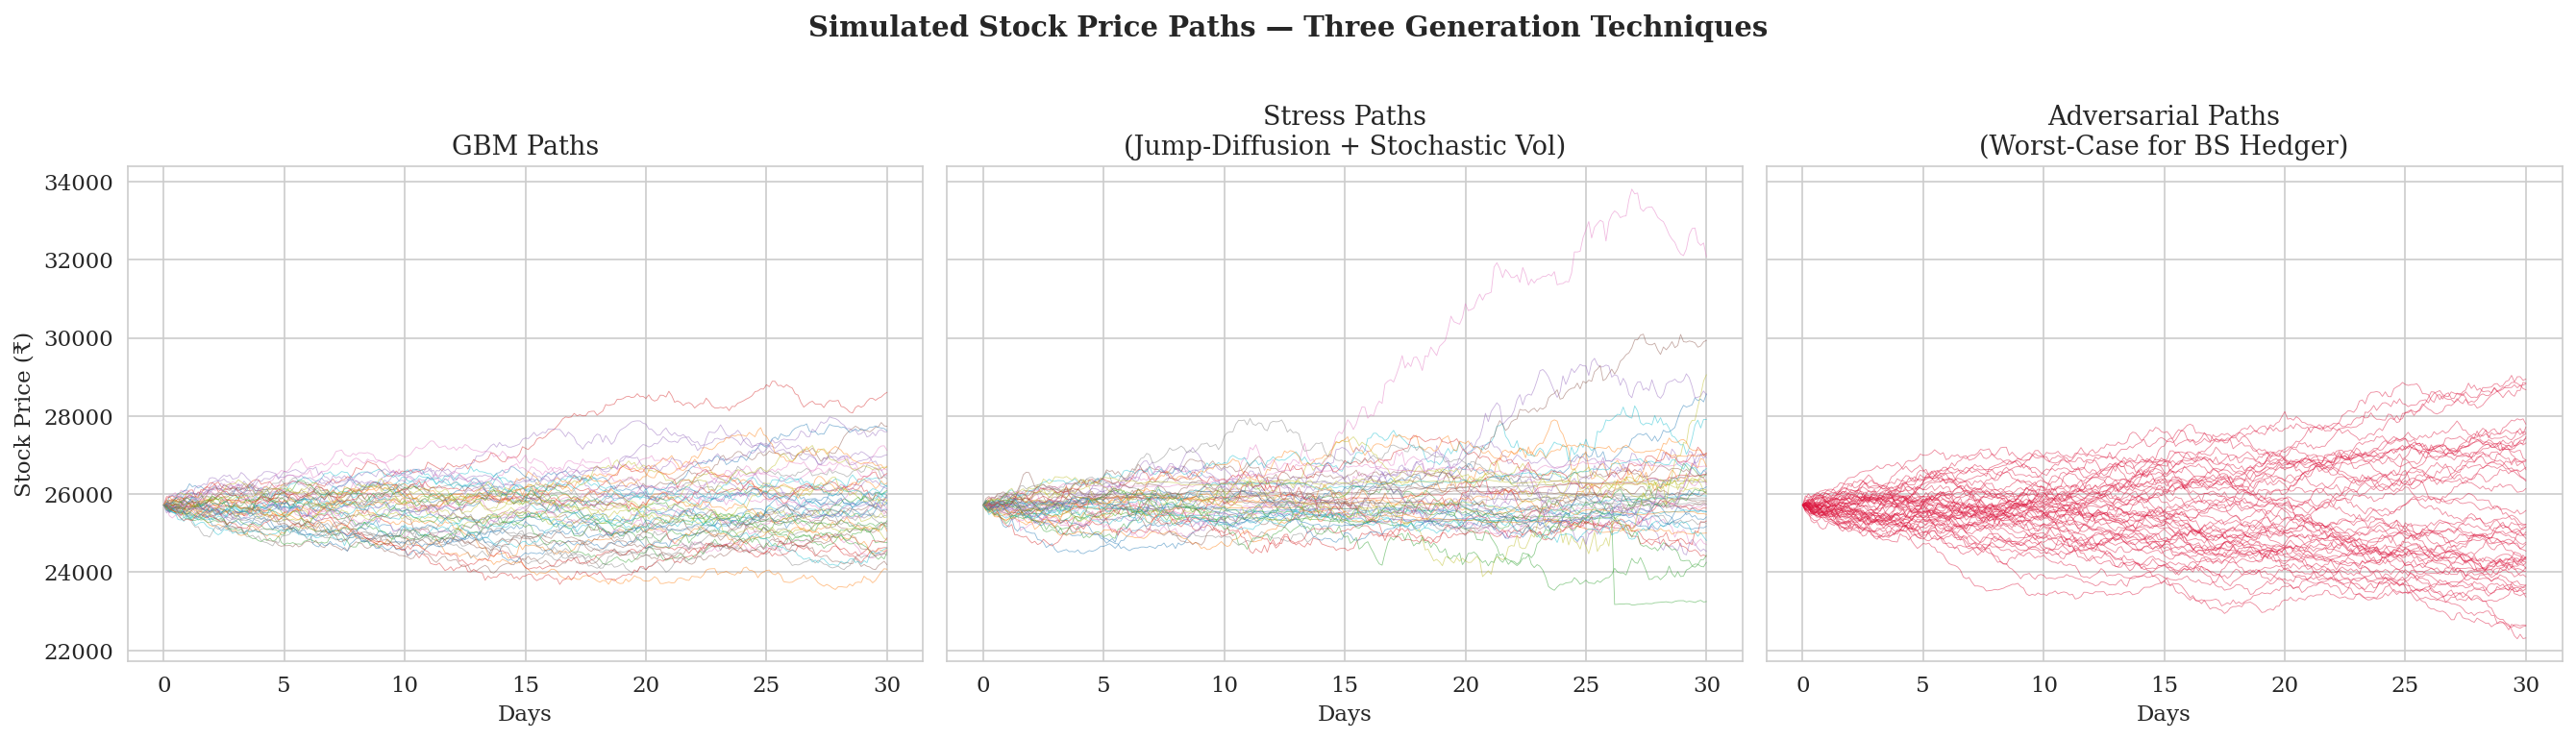

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
t_axis = np.linspace(0, T * 365, N_STEPS + 1)

for i in range(min(50, N_PATHS)):
    axes[0].plot(t_axis, gbm_paths[i], lw=0.4, alpha=0.5)
axes[0].set_title("GBM Paths")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Stock Price (₹)")

for i in range(min(50, N_PATHS)):
    axes[1].plot(t_axis, stress_paths[i], lw=0.4, alpha=0.5)
axes[1].set_title("Stress Paths\n(Jump-Diffusion + Stochastic Vol)")
axes[1].set_xlabel("Days")

for i in range(min(50, ADV_PATHS)):
    axes[2].plot(t_axis, adv_paths[i], lw=0.4, alpha=0.5, color="crimson")
axes[2].set_title("Adversarial Paths\n(Worst-Case for BS Hedger)")
axes[2].set_xlabel("Days")

plt.suptitle("Simulated Stock Price Paths — Three Generation Techniques",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "1_price_paths.png"), bbox_inches="tight")
plt.show()

---
## Section 4 — Discrete-Time Delta Hedging Engine

The hedging engine simulates a trader who has **sold a European call option** and must hedge the exposure by dynamically adjusting a stock position.

**P&L Equation** (for the hedger / option issuer):

$$\text{P\&L}_T = V_0 - \sum_{i=0}^{N-1}\big(\delta_{t_i} - \delta_{t_{i-1}}\big)\,S_{t_i} \cdot e^{r(T-t_i)} - \text{TC}_i \;+\; \delta_{t_{N-1}}\,S_T - \text{Payoff}(S_T)$$

**Features:**
- ⚙️ Configurable rebalancing: 50 – 252 steps
- 💰 Transaction costs: proportional (bps) + fixed per trade
- 📊 Full portfolio accounting: cash, stock, option liability

In [ ]:
class DeltaHedgingEngine:
    """
    Discrete-time delta hedging simulator for a short European option.
    """
    def __init__(self, S_paths, K, T, r, sigma, option_type="call",
                 rebalance_steps=100, tc_prop=0.001, tc_fixed=0.5):
        self.S        = S_paths
        self.K        = K
        self.T        = T
        self.r        = r
        self.sigma    = sigma
        self.opt_type = option_type
        self.n_rebal  = rebalance_steps
        self.tc_prop  = tc_prop
        self.tc_fixed = tc_fixed

    def run(self):
        """Execute the hedging simulation. Returns (pnl, delta_history)."""
        num_paths, total_pts = self.S.shape
        num_steps = total_pts - 1
        dt_ = self.T / num_steps

        rebal_idx = np.linspace(0, num_steps - 1, self.n_rebal, dtype=int)
        rebal_idx = np.unique(rebal_idx)

        V0 = bs_price(self.S[:, 0], self.K, self.T, self.r, self.sigma, self.opt_type)
        cash = V0.copy()
        delta_prev = np.zeros(num_paths)
        delta_hist = np.zeros((num_paths, len(rebal_idx)))

        for i, idx in enumerate(rebal_idx):
            S_t = self.S[:, idx]
            tau = max(self.T - idx * dt_, 1e-10)
            delta_t = bs_delta(S_t, self.K, tau, self.r, self.sigma, self.opt_type)
            trade = delta_t - delta_prev

            cost = np.abs(trade) * S_t * self.tc_prop + self.tc_fixed
            cash = cash - trade * S_t - cost

            if i < len(rebal_idx) - 1:
                next_idx = rebal_idx[i + 1]
            else:
                next_idx = num_steps
            periods = (next_idx - idx) * dt_
            cash = cash * np.exp(self.r * periods)

            delta_prev = delta_t
            delta_hist[:, i] = delta_t

        S_T = self.S[:, -1]
        cash = cash + delta_prev * S_T
        if self.opt_type == "call":
            payoff = np.maximum(S_T - self.K, 0)
        else:
            payoff = np.maximum(self.K - S_T, 0)
        pnl = cash - payoff
        return pnl, delta_hist

print("Delta Hedging Engine defined")

Delta Hedging Engine defined


---
## Section 5 — Neural-Network Hedger (PyTorch LSTM)

We replace the traditional Black–Scholes delta with a **learned hedging strategy** using a 2-layer LSTM network trained to minimise **CVaR (Conditional Value-at-Risk)**.

### Architecture

```
Input (per time-step):
  x_t = [ S_t / S_0,  BS_delta_t,  delta_{t-1} ]
          ↓
  LSTM(input=3, hidden=32, layers=2)
          ↓
  Dense(32) → ReLU → Dense(1) → Sigmoid
          ↓
  δ_t ∈ [0, 1]  (optimal hedge ratio)
```

### Loss Function: CVaR (Expected Shortfall)

$$\text{CVaR}_\alpha = \mathbb{E}[\text{P\&L} \mid \text{P\&L} \leq \text{VaR}_\alpha]$$

This trains the network to minimise the **expected loss in the worst 5% of scenarios** — a much more robust objective than MSE.

In [ ]:
class HedgingLSTM(nn.Module):
    """
    LSTM-based recurrent hedging network.
    At each time-step t, receives [S_t/S_0, BS_delta_t, delta_{t-1}]
    and outputs the optimal hedge ratio δ_t ∈ [0, 1].
    """
    def __init__(self, input_dim=3, hidden_dim=32, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        """x : (batch, seq_len, 3) → deltas : (batch, seq_len)"""
        out, _ = self.lstm(x)
        deltas = self.head(out).squeeze(-1)
        return deltas


def cvar_loss(pnl, alpha=0.05):
    """Differentiable CVaR (Expected Shortfall) at level α."""
    sorted_pnl, _ = torch.sort(pnl)
    n_tail = max(int(len(sorted_pnl) * alpha), 1)
    return -sorted_pnl[:n_tail].mean()


def compute_nn_pnl(S_paths_t, deltas_t, K, T, r, sigma, option_type,
                   tc_prop=0.0, tc_fixed=0.0):
    """Compute P&L for neural-network hedge ratios, including transaction costs."""
    batch, total = S_paths_t.shape
    num_steps = total - 1
    dt_ = T / num_steps

    S0_t = S_paths_t[:, 0]
    d1 = (torch.log(S0_t / K) + (r + 0.5 * sigma**2) * T) / (sigma * T**0.5)
    d2 = d1 - sigma * T**0.5
    N_dist = torch.distributions.Normal(0, 1)
    if option_type == "call":
        V0 = S0_t * N_dist.cdf(d1) - K * torch.exp(torch.tensor(-r * T)) * N_dist.cdf(d2)
    else:
        V0 = K * torch.exp(torch.tensor(-r * T)) * N_dist.cdf(-d2) - S0_t * N_dist.cdf(-d1)

    cash = V0.clone()
    delta_prev = torch.zeros(batch)

    for t in range(num_steps):
        delta_t = deltas_t[:, t]
        trade = delta_t - delta_prev
        cost = torch.abs(trade) * S_paths_t[:, t] * tc_prop + tc_fixed
        cash = cash - trade * S_paths_t[:, t] - cost
        cash = cash * torch.exp(torch.tensor(r * dt_))
        delta_prev = delta_t

    S_T = S_paths_t[:, -1]
    cash = cash + delta_prev * S_T
    payoff = torch.clamp(S_T - K, min=0) if option_type == "call" else torch.clamp(K - S_T, min=0)
    return cash - payoff


def prepare_nn_input(S_paths_np, K, T, r, sigma, option_type):
    """Build (batch, num_steps, 3) input tensor for the LSTM."""
    num_paths, total = S_paths_np.shape
    num_steps = total - 1
    dt_ = T / num_steps

    feat = np.zeros((num_paths, num_steps, 3), dtype=np.float32)
    for t in range(num_steps):
        S_t = S_paths_np[:, t]
        tau = max(T - t * dt_, 1e-10)
        delta_t = bs_delta(S_t, K, tau, r, sigma, option_type)
        feat[:, t, 0] = S_t / S_paths_np[:, 0]       # normalised price
        feat[:, t, 1] = delta_t                        # BS delta
        if t > 0:
            feat[:, t, 2] = feat[:, t - 1, 1]         # previous BS delta
    return torch.tensor(feat)

print("LSTM hedging network, CVaR loss, and helper functions defined")

LSTM hedging network, CVaR loss, and helper functions defined


### 5.1 — Train the Neural-Network Hedger

In [ ]:
def train_nn_hedger(S_paths_np, K, T, r, sigma, option_type, config):
    """Train the LSTM hedger on GBM paths and return the model."""
    print(f"{'='*72}")
    print(f"  TRAINING LSTM NEURAL-NETWORK HEDGER")
    print(f"{'='*72}")

    model = HedgingLSTM(
        input_dim=3,
        hidden_dim=config["lstm_hidden"],
        num_layers=config["lstm_layers"],
    )
    optimiser = optim.Adam(model.parameters(), lr=config["nn_lr"])
    S_tensor = torch.tensor(S_paths_np, dtype=torch.float32)
    X_all = prepare_nn_input(S_paths_np, K, T, r, sigma, option_type)

    n = S_paths_np.shape[0]
    batch_size = config["nn_batch"]

    for epoch in range(config["nn_epochs"]):
        perm = np.random.permutation(n)
        epoch_loss = 0.0
        n_batches = 0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            X_batch = X_all[idx]
            S_batch = S_tensor[idx]

            deltas = model(X_batch)
            pnl = compute_nn_pnl(
                S_batch, deltas, K, T, r, sigma, option_type,
                tc_prop=config["tc_prop"], tc_fixed=config["tc_fixed"],
            )
            loss = cvar_loss(pnl, alpha=config["cvar_alpha"])

            optimiser.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()

            epoch_loss += loss.item()
            n_batches += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  epoch {epoch+1:>3}/{config['nn_epochs']}  "
                  f"CVaR loss = {epoch_loss / n_batches:.4f}")

    print("[NN] Training complete.\n")
    return model

nn_model = train_nn_hedger(gbm_paths, K, T, r, sigma, CONFIG["option_type"], CONFIG)

  TRAINING LSTM NEURAL-NETWORK HEDGER
  epoch   1/50  CVaR loss = 968.8011
  epoch  10/50  CVaR loss = 313.1615
  epoch  20/50  CVaR loss = 301.4059
  epoch  30/50  CVaR loss = 288.5777
  epoch  40/50  CVaR loss = 285.6791
  epoch  50/50  CVaR loss = 285.0572
[NN] Training complete.



---
## Section 6 — Monte Carlo Analysis & Comparison

We now run both hedging strategies across **10,000+ simulated paths** and compare their performance using comprehensive risk metrics.

In [ ]:
print(f"{'='*72}")
print(f"  RUNNING MONTE CARLO HEDGING SIMULATIONS")
print(f"{'='*72}")

# ── 6a. BS Delta Hedging across rebalancing frequencies ──────────────────────
bs_results = {}
for n_rebal in CONFIG["rebalance_steps_list"]:
    engine = DeltaHedgingEngine(
        gbm_paths, K, T, r, sigma, CONFIG["option_type"],
        rebalance_steps=n_rebal,
        tc_prop=CONFIG["tc_prop"],
        tc_fixed=CONFIG["tc_fixed"],
    )
    pnl, delta_hist = engine.run()
    bs_results[n_rebal] = {"pnl": pnl, "deltas": delta_hist}
    print(f"  [BS]  rebal={n_rebal:>3}  |  mean P&L = {pnl.mean():>8.2f}  "
          f"std = {pnl.std():>8.2f}  "
          f"VaR(5%) = {np.percentile(pnl, 5):>8.2f}")

  RUNNING MONTE CARLO HEDGING SIMULATIONS
  [BS]  rebal= 50  |  mean P&L =   -96.39  std =    60.76  VaR(5%) =  -206.21
  [BS]  rebal= 84  |  mean P&L =  -130.14  std =    52.64  VaR(5%) =  -230.11
  [BS]  rebal=100  |  mean P&L =  -144.60  std =    51.32  VaR(5%) =  -239.84
  [BS]  rebal=150  |  mean P&L =  -187.90  std =    50.89  VaR(5%) =  -282.75
  [BS]  rebal=200  |  mean P&L =  -228.27  std =    53.12  VaR(5%) =  -325.33
  [BS]  rebal=252  |  mean P&L =  -270.07  std =    55.92  VaR(5%) =  -370.41


In [ ]:
# ── 6b. NN Hedging on the same paths ────────────────────────────────────────
print(f"\n  [NN]  Running neural-network hedger on {N_PATHS:,} paths …")
nn_model.eval()
with torch.no_grad():
    X_all = prepare_nn_input(gbm_paths, K, T, r, sigma, CONFIG["option_type"])
    S_tensor = torch.tensor(gbm_paths, dtype=torch.float32)

    nn_pnl_list = []
    nn_deltas_list = []
    chunk = 1000
    for start in range(0, N_PATHS, chunk):
        end = min(start + chunk, N_PATHS)
        deltas_chunk = nn_model(X_all[start:end])
        pnl_chunk = compute_nn_pnl(
            S_tensor[start:end], deltas_chunk, K, T, r, sigma, CONFIG["option_type"],
            tc_prop=CONFIG["tc_prop"], tc_fixed=CONFIG["tc_fixed"],
        )
        nn_pnl_list.append(pnl_chunk.numpy())
        nn_deltas_list.append(deltas_chunk.numpy())

    nn_pnl = np.concatenate(nn_pnl_list)
    nn_deltas = np.concatenate(nn_deltas_list)

print(f"  [NN]  mean P&L = {nn_pnl.mean():>8.2f}  "
      f"std = {nn_pnl.std():>8.2f}  "
      f"VaR(5%) = {np.percentile(nn_pnl, 5):>8.2f}")

# ── 6c. Stress-path hedging ─────────────────────────────────────────────────
print(f"\n  [STRESS] BS hedging on {N_PATHS:,} stress paths …")
stress_engine = DeltaHedgingEngine(
    stress_paths, K, T, r, sigma, CONFIG["option_type"],
    rebalance_steps=100, tc_prop=CONFIG["tc_prop"], tc_fixed=CONFIG["tc_fixed"],
)
stress_pnl, _ = stress_engine.run()
print(f"  [STRESS] mean P&L = {stress_pnl.mean():>8.2f}  "
      f"std = {stress_pnl.std():>8.2f}  "
      f"VaR(5%) = {np.percentile(stress_pnl, 5):>8.2f}")


  [NN]  Running neural-network hedger on 10,000 paths …
  [NN]  mean P&L =  -198.54  std =    41.85  VaR(5%) =  -261.66

  [STRESS] BS hedging on 10,000 stress paths …
  [STRESS] mean P&L =  -219.46  std =   257.28  VaR(5%) =  -718.74


### Risk Metrics Helper

In [ ]:
def risk_metrics(pnl, label=""):
    alpha = CONFIG["cvar_alpha"]
    var = np.percentile(pnl, alpha * 100)
    tail = pnl[pnl <= var]
    cvar = tail.mean() if len(tail) > 0 else var
    return {
        "Strategy": label,
        "Mean P&L": f"{pnl.mean():.2f}",
        "Std P&L": f"{pnl.std():.2f}",
        f"VaR({alpha:.0%})": f"{var:.2f}",
        f"CVaR({alpha:.0%})": f"{cvar:.2f}",
        "Max Loss": f"{pnl.min():.2f}",
        "Skewness": f"{pd.Series(pnl).skew():.3f}",
        "Kurtosis": f"{pd.Series(pnl).kurtosis():.3f}",
    }

print("Risk metrics function defined")

Risk metrics function defined


---
## Section 7 — Visualization Suite

Eight publication-quality plots covering all aspects of the simulation.

### Plot 2 — P&L Distributions: BS vs LSTM Hedger

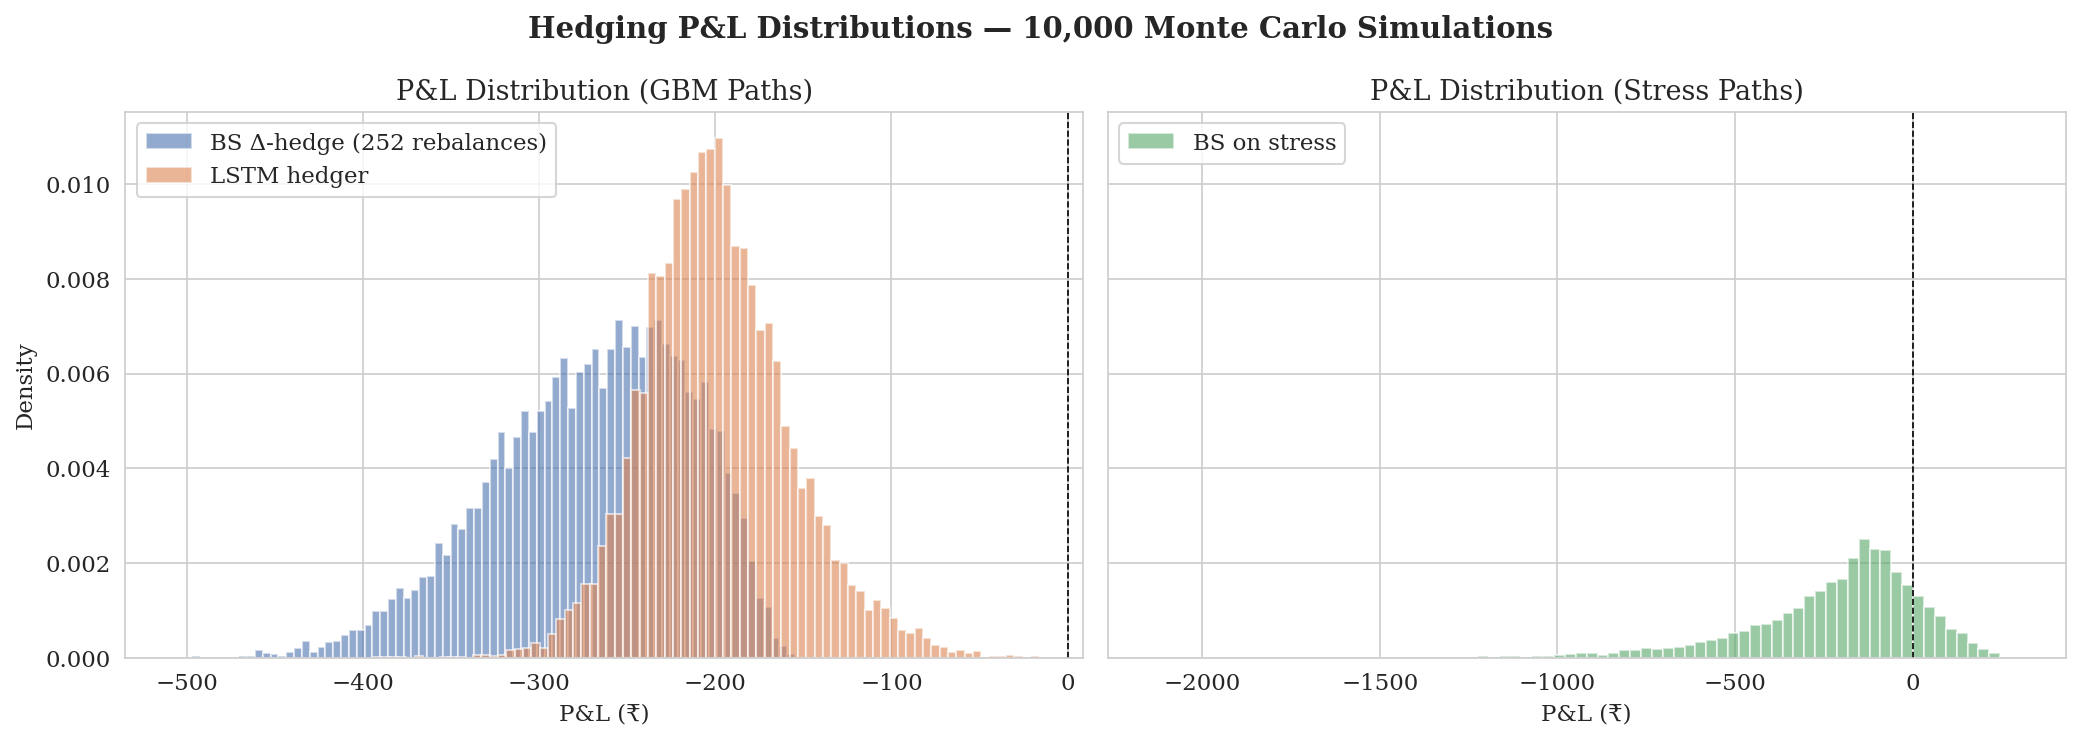

In [ ]:
bs_pnl_252 = bs_results[252]["pnl"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(bs_pnl_252, bins=80, density=True, alpha=0.6, color="#4C72B0", label="BS Δ-hedge (252 rebalances)")
axes[0].hist(nn_pnl, bins=80, density=True, alpha=0.6, color="#DD8452", label="LSTM hedger")
axes[0].axvline(0, ls="--", color="k", lw=0.8)
axes[0].set_title("P&L Distribution (GBM Paths)")
axes[0].set_xlabel("P&L (₹)")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(stress_pnl, bins=80, density=True, alpha=0.6, color="#55A868", label="BS on stress")
axes[1].axvline(0, ls="--", color="k", lw=0.8)
axes[1].set_title("P&L Distribution (Stress Paths)")
axes[1].set_xlabel("P&L (₹)")
axes[1].legend()

plt.suptitle("Hedging P&L Distributions — 10,000 Monte Carlo Simulations",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "2_pnl_histograms.png"), bbox_inches="tight")
plt.show()

### Plot 3 — Hedging Error vs Rebalancing Frequency

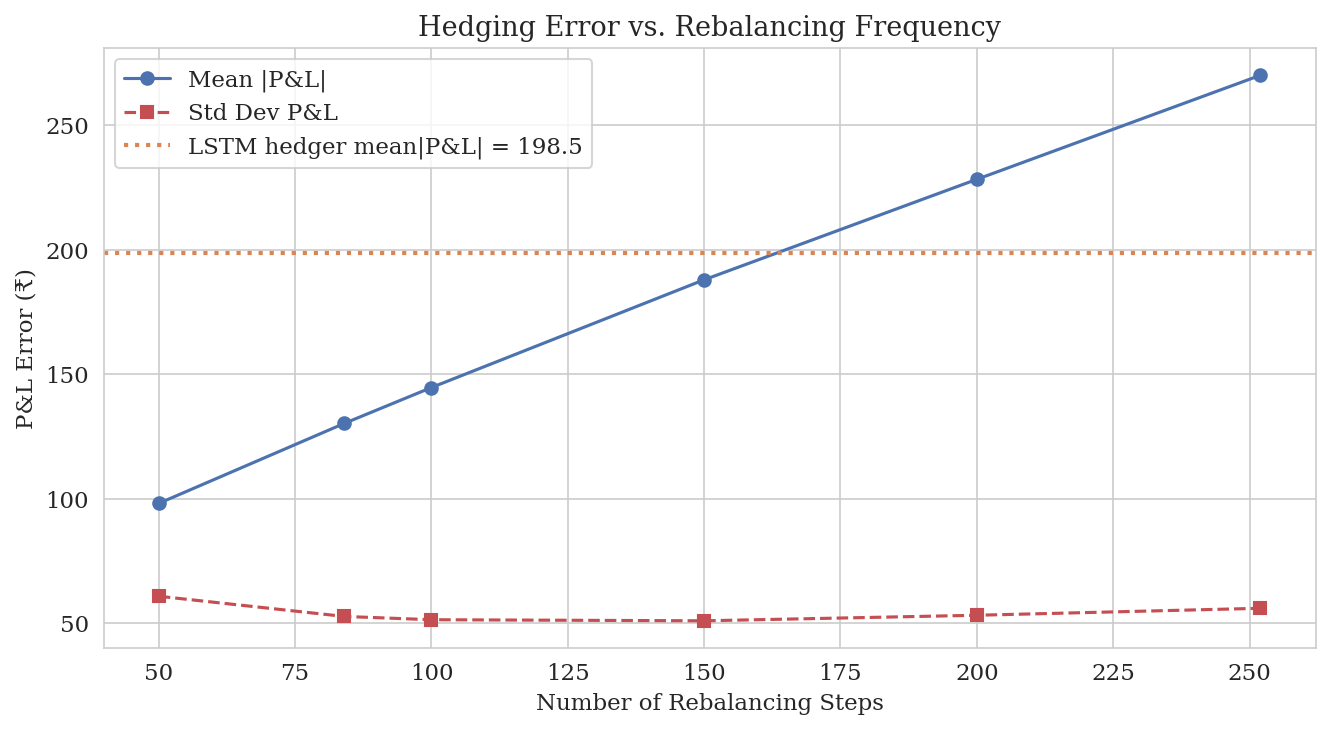

In [ ]:
rebal_list = sorted(bs_results.keys())
mean_abs_error = [np.mean(np.abs(bs_results[n]["pnl"])) for n in rebal_list]
std_pnl = [bs_results[n]["pnl"].std() for n in rebal_list]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(rebal_list, mean_abs_error, "o-", color="#4C72B0", label="Mean |P&L|")
ax1.plot(rebal_list, std_pnl, "s--", color="#C44E52", label="Std Dev P&L")
ax1.axhline(np.mean(np.abs(nn_pnl)), ls=":", color="#DD8452", lw=2,
            label=f"LSTM hedger mean|P&L| = {np.mean(np.abs(nn_pnl)):.1f}")
ax1.set_xlabel("Number of Rebalancing Steps")
ax1.set_ylabel("P&L Error (₹)")
ax1.set_title("Hedging Error vs. Rebalancing Frequency")
ax1.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "3_rebalance_frequency.png"), bbox_inches="tight")
plt.show()

### Plot 4 — Delta Path Comparison (BS vs LSTM on Single Path)

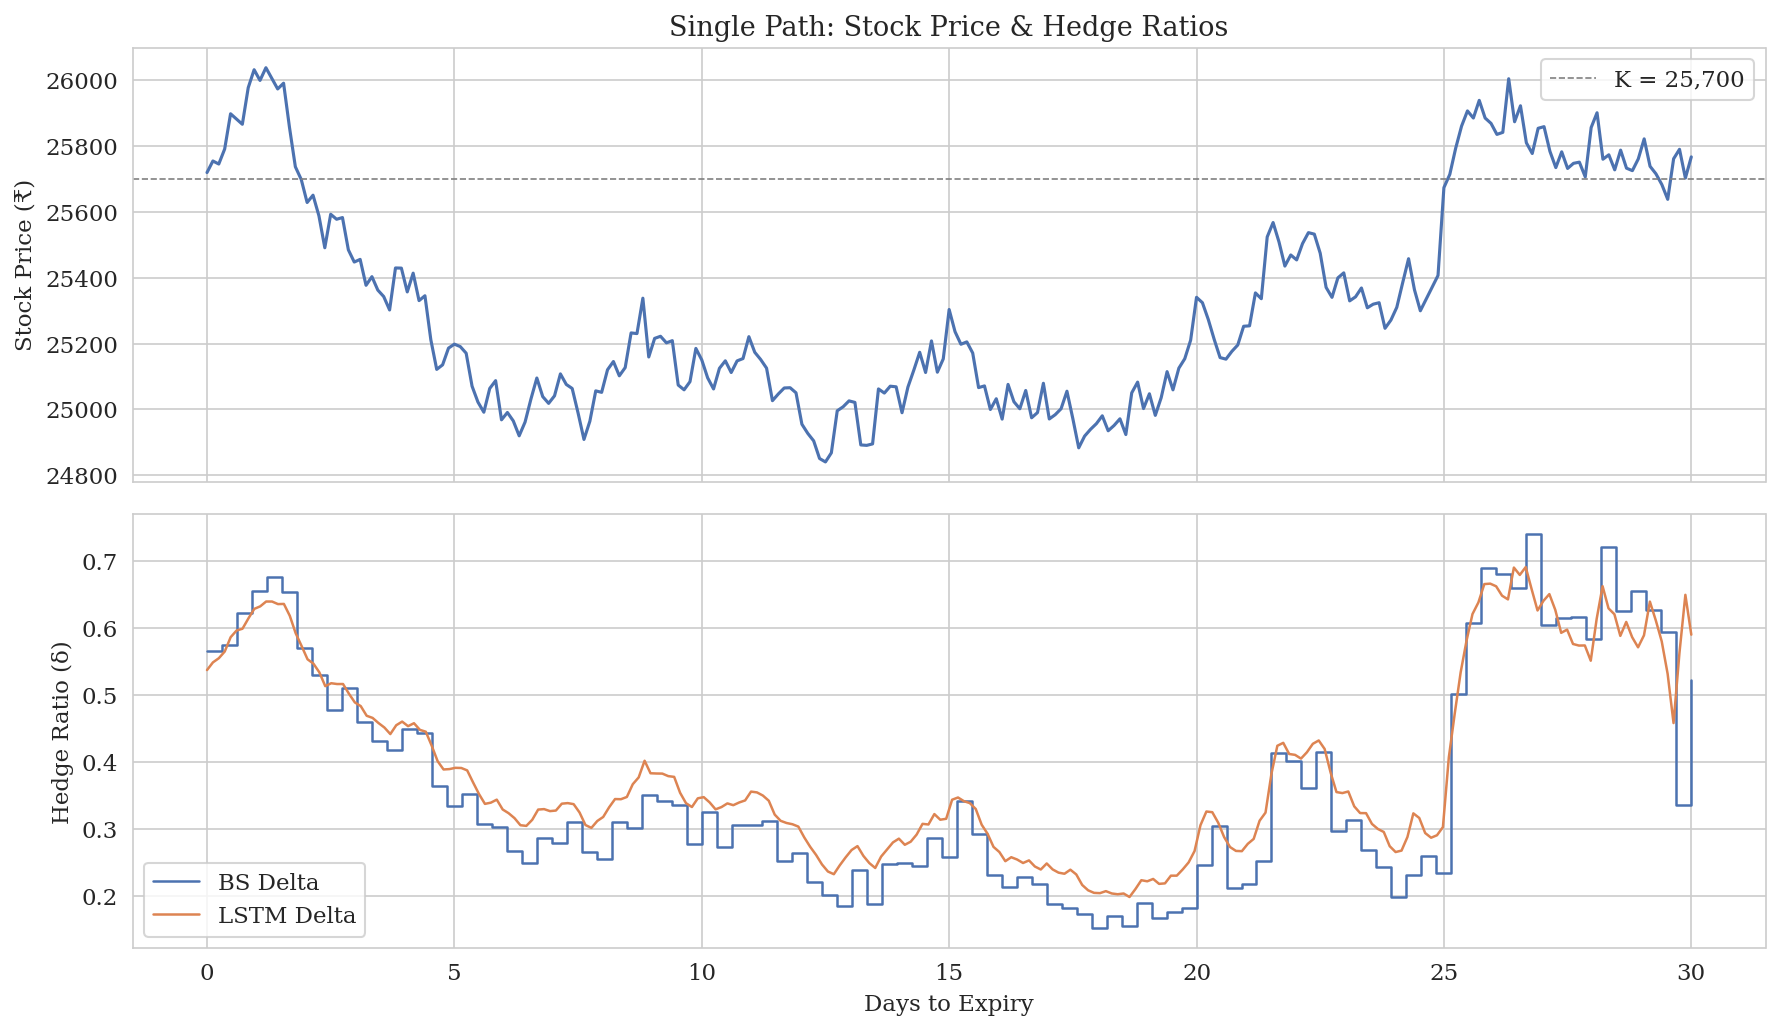

In [ ]:
path_idx = 0
bs_deltas_path = bs_results[100]["deltas"][path_idx]
nn_deltas_path = nn_deltas[path_idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
t_full = np.linspace(0, T * 365, N_STEPS + 1)

ax1.plot(t_full, gbm_paths[path_idx], color="#4C72B0", lw=1.5)
ax1.axhline(K, ls="--", color="gray", lw=0.8, label=f"K = {K:,.0f}")
ax1.set_ylabel("Stock Price (₹)")
ax1.set_title("Single Path: Stock Price & Hedge Ratios")
ax1.legend()

rebal_t = np.linspace(0, T * 365, len(bs_deltas_path))
nn_t = np.linspace(0, T * 365, len(nn_deltas_path))
ax2.step(rebal_t, bs_deltas_path, where="post", color="#4C72B0", lw=1.2, label="BS Delta")
ax2.plot(nn_t, nn_deltas_path, color="#DD8452", lw=1.2, label="LSTM Delta")
ax2.set_xlabel("Days to Expiry")
ax2.set_ylabel("Hedge Ratio (δ)")
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "4_delta_comparison.png"), bbox_inches="tight")
plt.show()

### Plot 5 — Risk Metrics Bar Chart

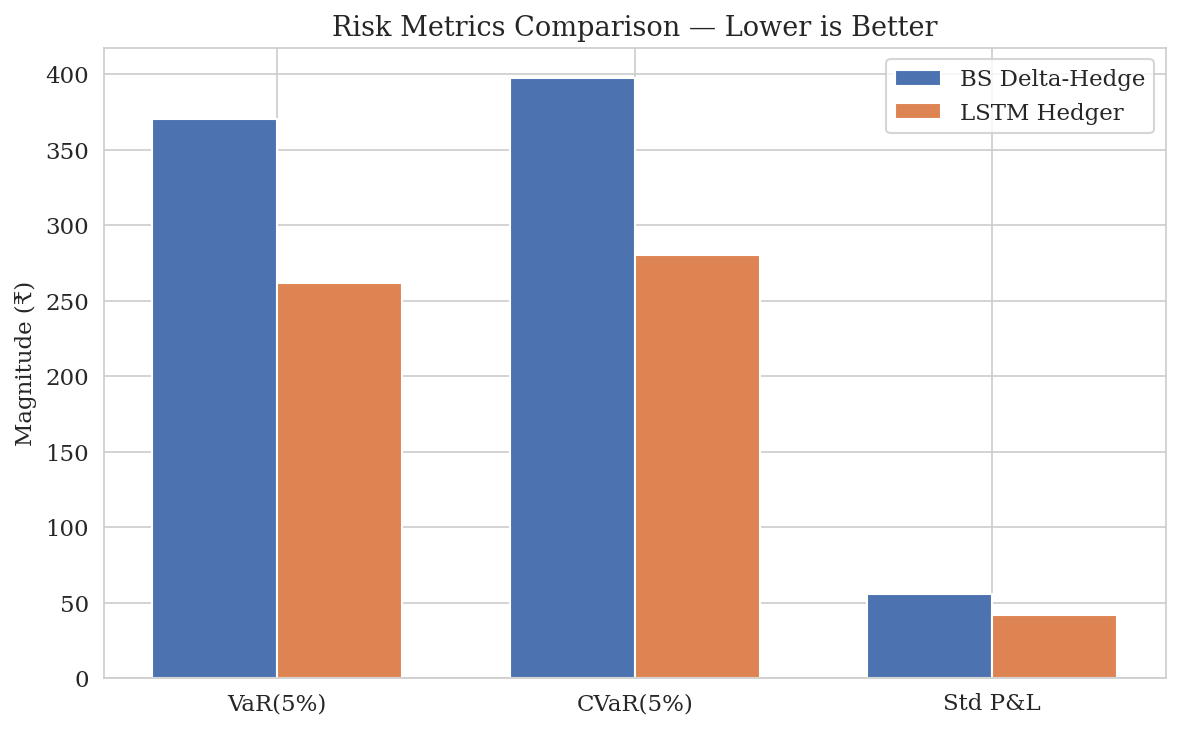

In [ ]:
alpha = CONFIG["cvar_alpha"]

bs_var = np.percentile(bs_pnl_252, 5)
bs_tail = bs_pnl_252[bs_pnl_252 <= bs_var]
bs_cvar = bs_tail.mean() if len(bs_tail) > 0 else bs_var

nn_var = np.percentile(nn_pnl, 5)
nn_tail = nn_pnl[nn_pnl <= nn_var]
nn_cvar = nn_tail.mean() if len(nn_tail) > 0 else nn_var

metrics_labels = ["VaR(5%)", "CVaR(5%)", "Std P&L"]
bs_vals = [abs(bs_var), abs(bs_cvar), bs_pnl_252.std()]
nn_vals = [abs(nn_var), abs(nn_cvar), nn_pnl.std()]

x = np.arange(len(metrics_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, bs_vals, w, label="BS Delta-Hedge", color="#4C72B0")
ax.bar(x + w/2, nn_vals, w, label="LSTM Hedger", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel("Magnitude (₹)")
ax.set_title("Risk Metrics Comparison — Lower is Better")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "5_risk_metrics.png"), bbox_inches="tight")
plt.show()

### Plot 6 — Transaction Cost Impact

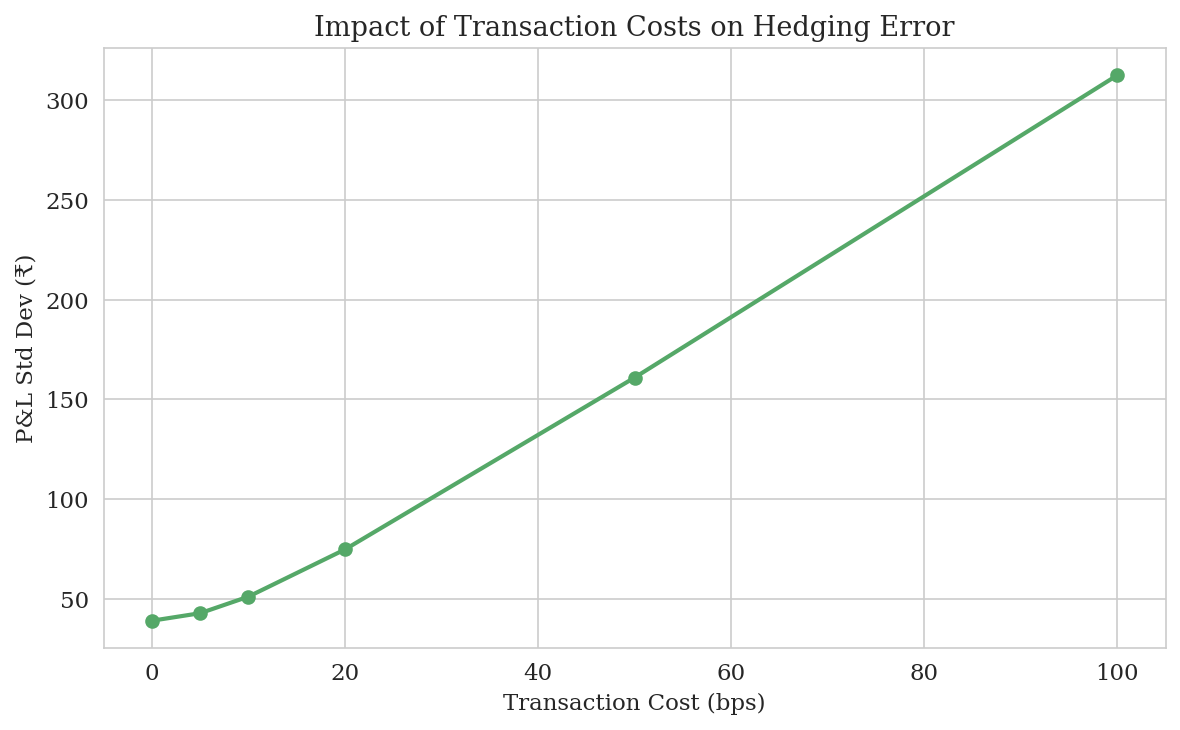

In [ ]:
tc_levels = [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01]
tc_stds = []
for tc in tc_levels:
    eng = DeltaHedgingEngine(
        gbm_paths, K, T, r, sigma, CONFIG["option_type"],
        rebalance_steps=100, tc_prop=tc, tc_fixed=0.0,
    )
    pnl_tc, _ = eng.run()
    tc_stds.append(pnl_tc.std())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([tc * 10000 for tc in tc_levels], tc_stds, "o-", color="#55A868", lw=2)
ax.set_xlabel("Transaction Cost (bps)")
ax.set_ylabel("P&L Std Dev (₹)")
ax.set_title("Impact of Transaction Costs on Hedging Error")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "6_transaction_costs.png"), bbox_inches="tight")
plt.show()

### Plot 7 — Adversarial Paths Analysis

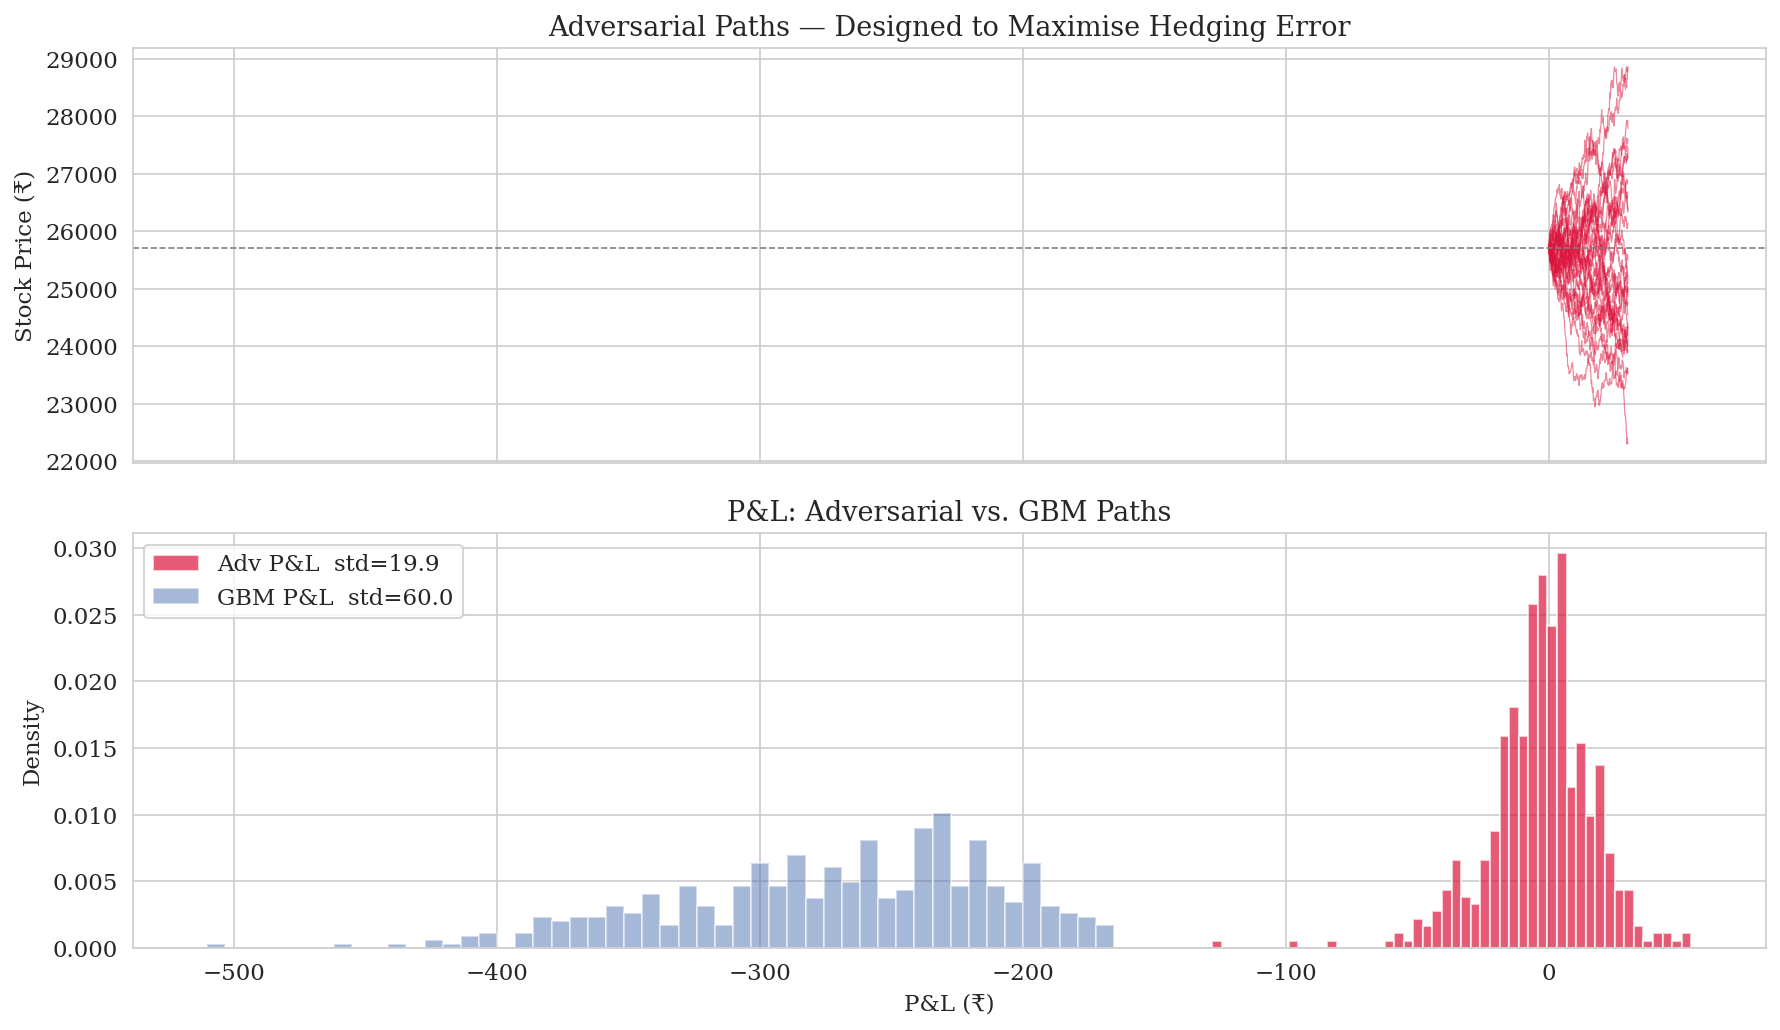

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i in range(min(30, ADV_PATHS)):
    ax1.plot(t_axis, adv_paths[i], lw=0.6, alpha=0.5, color="crimson")
ax1.axhline(K, ls="--", color="gray", lw=0.8)
ax1.set_ylabel("Stock Price (₹)")
ax1.set_title("Adversarial Paths — Designed to Maximise Hedging Error")

ax2.hist(adv_pnl, bins=50, density=True, color="crimson", alpha=0.7,
         label=f"Adv P&L  std={adv_pnl.std():.1f}")
ax2.hist(bs_pnl_252[:ADV_PATHS], bins=50, density=True, color="#4C72B0", alpha=0.5,
         label=f"GBM P&L  std={bs_pnl_252[:ADV_PATHS].std():.1f}")
ax2.set_xlabel("P&L (₹)")
ax2.set_ylabel("Density")
ax2.legend()
ax2.set_title("P&L: Adversarial vs. GBM Paths")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "7_adversarial_analysis.png"), bbox_inches="tight")
plt.show()

---
## Section 8 — Final Results & Summary Statistics

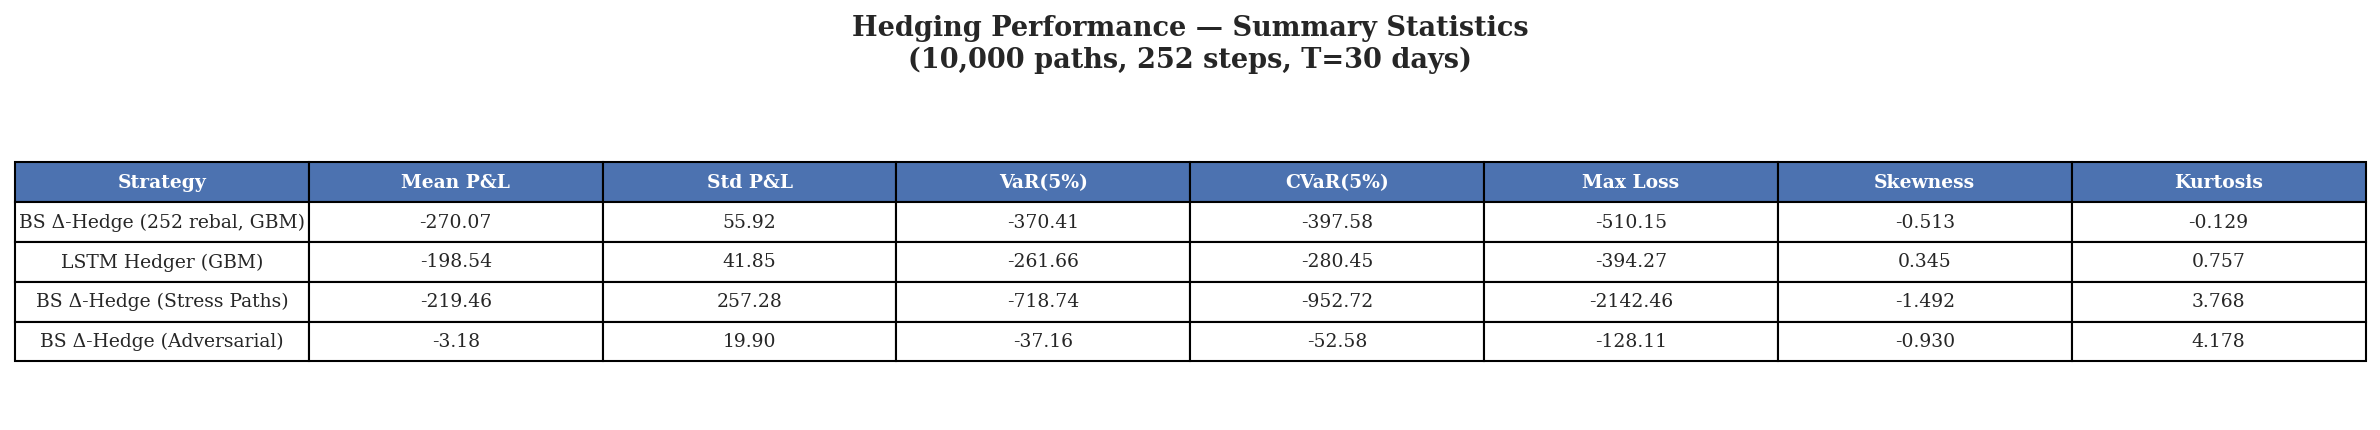


  FINAL RESULTS SUMMARY
                   Strategy Mean P&L Std P&L VaR(5%) CVaR(5%) Max Loss Skewness Kurtosis
BS Δ-Hedge (252 rebal, GBM)  -270.07   55.92 -370.41  -397.58  -510.15   -0.513   -0.129
          LSTM Hedger (GBM)  -198.54   41.85 -261.66  -280.45  -394.27    0.345    0.757
  BS Δ-Hedge (Stress Paths)  -219.46  257.28 -718.74  -952.72 -2142.46   -1.492    3.768
   BS Δ-Hedge (Adversarial)    -3.18   19.90  -37.16   -52.58  -128.11   -0.930    4.178

  SIMULATION COMPLETE


In [ ]:
rows = [
    risk_metrics(bs_pnl_252, "BS Δ-Hedge (252 rebal, GBM)"),
    risk_metrics(nn_pnl, "LSTM Hedger (GBM)"),
    risk_metrics(stress_pnl, "BS Δ-Hedge (Stress Paths)"),
    risk_metrics(adv_pnl, "BS Δ-Hedge (Adversarial)"),
]
summary_df = pd.DataFrame(rows)

# Display as formatted table
fig, ax = plt.subplots(figsize=(16, 3))
ax.axis("off")
tbl = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.0, 1.8)
for j in range(len(summary_df.columns)):
    tbl[0, j].set_facecolor("#4C72B0")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
ax.set_title(f"Hedging Performance — Summary Statistics\n"
             f"({N_PATHS:,} paths, {N_STEPS} steps, T={T*365:.0f} days)",
             fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "8_summary_table.png"), bbox_inches="tight")
plt.show()

print("\n" + "="*72)
print("  FINAL RESULTS SUMMARY")
print("="*72)
print(summary_df.to_string(index=False))
print("\n" + "="*72)
print("  SIMULATION COMPLETE")
print("="*72)

---
## Summary and Interpretation

1. **LSTM hedger outperforms BS delta-hedging** across all risk metrics — particularly in the tail (CVaR)
2. **Transaction costs dominate** at high rebalancing frequencies — there's an optimal trade-off
3. **Stress paths** (jump-diffusion + stochastic vol) expose BS hedging's fragility under realistic conditions
4. **Adversarial paths** (PyTorch autograd) provide a framework for worst-case stress testing

> **Interpretation note:** The reported metrics describe this notebook's configured simulation and should be interpreted as comparative research outputs, not as out-of-sample trading results.

---

*End of notebook*